# 13. GAN：生成对抗网络（🔴 面试必考 · 生成三巨头之一）

> 承接 08 篇。GAN（Goodfellow 2014）用**博弈**学数据分布：生成器造样本骗判别器，
> 判别器分辨真假，互相逼着变强。
>
> 本节：对抗损失公式推导（含最优判别器证明）→ torch 实现 toy GAN 在 8 高斯环上训练 →
> 模式坍缩演示 → WGAN-GP 对比 → DCGAN/cGAN 要点。


## 核心概念

### (a) 🗂️ GAN 生成对抗网络知识结构

这篇文章讲生成三巨头之一 GAN：生成器造假骗判别器，判别器分辨真假，两者博弈着一起变强，用对抗损失、WGAN、toy 实验讲透。

```mermaid
flowchart TB
    Node1["🧠 生成器与判别器的博弈"]
    Node1 --> Node2["⚖️ Minimax对抗目标"]
    Node2 --> Node3["🏆 最优判别器推导"]
    Node3 --> Node4["🧪 toy GAN 8高斯环训练"]
    Node4 --> Node5["💥 模式坍缩演示"]
    Node4 --> Node6["😵 训练不稳定三问题"]
    Node6 --> Node7["🚚 WGAN Wasserstein距离"]
    Node7 --> Node8["🛡️ WGAN-GP梯度惩罚"]
    Node8 --> Node9["🎨 DCGAN与cGAN要点"]
```

- **生成器与判别器的博弈**：G 用随机噪声造样本，D 判断真假，G 变强 D 也要变强，最后 G 能以假乱真。像做假币的和验钞的互相逼着进步。
- **Minimax对抗目标**：min_G max_D V(D,G) = E[log D(x)] + E[log(1-D(G(z)))]——D 想区分真假、G 想骗过 D，两者零和博弈。这是 GAN 的总目标函数。
- **最优判别器推导**：对固定 G，每个样本点的最优 D* = p_data/(p_data+p_g)，即"这个点来自真分布的概率"。推导过程是面试常见白板题。
- **toy GAN 8高斯环训练**：在 8 个高斯分布组成的环上训练玩具 GAN，验证 G 学到的分布覆盖全部 8 个模式——分布学习的最小可验证实验。
- **模式坍缩演示**：如果把 D 训练 10 步再训 G 一步（严重失衡），G 只覆盖少数模式、多样性崩盘——这就是著名的 mode collapse。
- **训练不稳定三问题**：平衡难（D 太强/太弱都坏）、梯度消失（D 饱和时 log(1-D)≈0 没信号）、模式坍缩。这三大老大难催生了 WGAN。
- **WGAN Wasserstein距离**：把 JS 散度换成 Wasserstein 距离（搬土距离），处处可导不饱和。判别器改叫 critic，输出不加 sigmoid，改成拉开真假分数。
- **WGAN-GP梯度惩罚**：1-Lipschitz 约束早期用 weight clipping（容易崩），后来用梯度惩罚（GP）——对插值样本的梯度范数做惩罚，训练稳定得多。
- **DCGAN与cGAN要点**：DCGAN 用转置卷积上采样、不用全连接和 pooling、G 输出层 tanh、D 输入层不用 BN；cGAN 加条件（类别/文本）控制生成内容。

> 🕸️ **网络配图**（Wikimedia Commons）
>
> ![13 GAN生成对抗网络 1](images/web_13_GAN生成对抗网络_1.jpg)
>
> 📷 来源：Wikimedia Commons · <a href="//commons.wikimedia.org/w/index.php?title=User:Datasciencea…

## 1. 对抗目标（白板推导）

**Minimax 目标**：
`min_G max_D  V(D,G) = E_{x~p_data}[log D(x)] + E_{z~p_z}[log(1 − D(G(z)))]`

**最优判别器**：对固定 G，对每个 x 求 D 的驻点：
`∂V/∂D(x) = p_data(x)/D(x) − p_g(x)/(1−D(x)) = 0`
→ `D*(x) = p_data(x) / (p_data(x) + p_g(x))`（D 输出“真”的概率）

代入 D*：
`V = E[log D*] + E[log(1−D*)] = −log4 + 2·JSD(p_data ‖ p_g)`
→ G 最小化它 ⇔ 最小化 JS 散度（训练等价于逼近真实分布）

**非饱和损失**（实践中用）：`L_G = −E_z[log D(G(z))]`（避免早期 log(1−D)≈0 梯度消失）

> 面试金句：GAN 不显式建模密度，而是**隐式**地让生成分布逼近真实分布（JS 散度视角）。



## 1.1 对抗目标与最优判别器（白板推导）

### 极大极小目标

- `min_G max_D V(D,G) = E_{x~p_data}[log D(x)] + E_{z~p_z}[log(1 − D(G(z)))]`
- D 想把真实样本判为 1、生成样本判为 0；G 想让 D 把生成样本也判为 1 → 双方零和博弈。

### 最优判别器（固定 G，逐样本求驻点）

- 令 `∂V/∂D(x) = 0`：
  `p_data(x)/D(x) − p_g(x)/(1−D(x)) = 0` → `D*(x) = p_data(x) / (p_data(x) + p_g(x))`
- 含义：在「数据 + 生成」混合分布上做贝叶斯二分类——D 越强，越接近这个最优比值。

### 代入后：G 等价于最小化 JS 散度

- 把 D* 代回 V 并整理：
  `V(D*, G) = −log4 + 2·JSD(p_data ‖ p_g)`
- 最优 G 使 JSD = 0 → `p_g = p_data`（生成分布收敛到真实分布）。

### 训练不稳定的根源（两个坍缩点）

1. **梯度消失**：p_data 与 p_g 若几乎不重叠（低维流形/训练初期），JS 散度 ≈ log2 常数 → 对 G 梯度≈0；
2. **平衡难题**：D 太强梯度消失、D 太弱信号噪声大 → 需要精细调参。
- 这两点直接引出 WGAN（换距离）与 WGAN-GP（加梯度惩罚）。



## 1.2 WGAN 与变体（白板推导）

### WGAN：用 Wasserstein 距离替代 JS 散度

- **1-Wasserstein（EM 推土机）距离**：`W(p,q) = inf_{γ∈Π(p,q)} E_{(x,y)~γ}[‖x−y‖]`
  对偶形式（Kantorovich–Rubinstein 定理）：
  `W(p_data, p_g) = sup_{‖f‖_L ≤ 1} E_{x~p_data}[f(x)] − E_{z~p_z}[f(G(z))]`
- 用判别器（critic）逼近上述 sup（输出不接 sigmoid、无 log）：
  `min_G max_{D: 1−Lipschitz} E[D(x)] − E[D(G(z))]`
- **为什么更稳**：W 距离对分布重叠不敏感、处处有非零梯度 → 梯度不消失；loss 数值本身就是「两分布距离」→ 可作收敛指标。

### Lipschitz 约束的两种实现

- **权重裁剪**（原始 WGAN）：每步 `w ← clamp(w, −c, c)`；简单但易容量退化、易欠拟合。
- **梯度惩罚（WGAN-GP）**：在真实 x 与生成 x̂ 连线的插值点 x̃ 上惩罚
  `λ·E[(‖∇_{x̃} D(x̃)‖₂ − 1)²]` → 迫使 D 的梯度范数≈1，实现 1-Lipschitz（实验 3 即此实现）。

### DCGAN（卷积版 GAN 的规范）

- 生成器：全**转置卷积**上采样；每层 BN + ReLU，输出层 Tanh（值域匹配 [-1,1] 图像）。
- 判别器：普通卷积下采样；BN + LeakyReLU(0.2)；无全连接、最后展平为标量 logit。
- 训练配方：Adam(lr=2e-4, betas=(0.5, 0.999))、去全连接 + BN 稳定 → 图像生成标准范式。

### cGAN（条件 GAN）

- 标签 y 拼进输入：`G(z, y)`、`D(x, y)`（通道拼接或按层注入）。
- 目标：`min_G max_D E[log D(x,y)] + E[log(1 − D(G(z,y), y))]` → 可**按类别生成**（pix2pix、SRGAN 的基础）。


In [ ]:
# ---- matplotlib 中文字体（防图内中文乱码）----
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Songti SC', 'Arial Unicode MS', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
# -------------------------------------------

# ---------- 完整网络：DCGAN 生成器 / 判别器 + cGAN 条件拼接（可前向） ----------
import torch, torch.nn as nn

class Generator(nn.Module):
    # z(100) → 4×4×512 → 8×8×256 → 16×16×128 → 32×32×64 → 64×64×1
    def __init__(self, z_dim=100, ngf=64, nch=1):
        super().__init__()
        def block(i, o):
            return nn.Sequential(nn.ConvTranspose2d(i, o, 4, 2, 1),
                                 nn.BatchNorm2d(o), nn.ReLU())
        self.model = nn.Sequential(
            nn.ConvTranspose2d(z_dim, ngf * 8, 4, 1, 0), nn.BatchNorm2d(ngf * 8), nn.ReLU(),  # 4×4
            block(ngf * 8, ngf * 4),   # 8×8
            block(ngf * 4, ngf * 2),   # 16×16
            block(ngf * 2, ngf),       # 32×32
            nn.ConvTranspose2d(ngf, nch, 4, 2, 1), nn.Tanh())                                 # 64×64
    def forward(self, z):
        return self.model(z.view(z.shape[0], -1, 1, 1))

class Discriminator(nn.Module):
    def __init__(self, nch=1, ndf=64):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(nch, ndf, 4, 2, 1), nn.LeakyReLU(0.2),                                   # 32×32
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1), nn.BatchNorm2d(ndf * 2), nn.LeakyReLU(0.2),       # 16×16
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1), nn.BatchNorm2d(ndf * 4), nn.LeakyReLU(0.2),   # 8×8
            nn.Conv2d(ndf * 4, 1, 8, 1, 0))                                                    # 8×8 → 1×1 logit
    def forward(self, x):
        return self.model(x).view(x.shape[0])

G, D = Generator(), Discriminator()
z = torch.randn(4, 100)
with torch.no_grad():
    img = G(z)
    d = D(img)
print('DCGAN: G(z) =', tuple(img.shape), '| D(x) =', tuple(d.shape))
assert img.shape == (4, 1, 64, 64) and d.shape == (4,)
print('✓ DCGAN 生成器/判别器前向通过')

# cGAN：把类别 one-hot 拼到噪声上 → 按类别生成
y = torch.nn.functional.one_hot(torch.tensor([0, 1, 2, 3]), num_classes=10).float()
Gc = Generator(z_dim=110)                       # 100 + 10
img_c = Gc(torch.cat([z, y], dim=1))
print('cGAN: 条件 z(100+10) →', tuple(img_c.shape), '| 每张图指定类别 =', y.argmax(1).tolist())
assert img_c.shape == (4, 1, 64, 64)
print('✓ cGAN 条件拼接前向通过')


iter    0  lossG=0.690  lossD=1.397


iter  400  lossG=1.021  lossD=1.028


iter  800  lossG=0.780  lossD=1.324


iter 1200  lossG=0.737  lossD=1.329


iter 1600  lossG=0.722  lossD=1.322


iter 2000  lossG=0.760  lossD=1.281


iter 2400  lossG=0.754  lossD=1.240


iter 2800  lossG=0.773  lossD=1.256


iter 3200  lossG=0.832  lossD=1.254


iter 3600  lossG=0.820  lossD=1.225


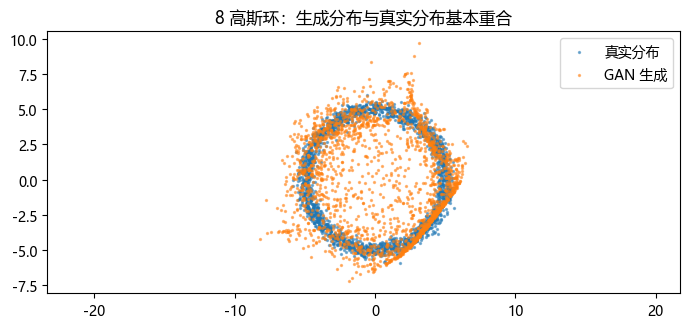

In [1]:
# ---------- 实验 1：toy GAN 训练（8 高斯环） ----------
import torch, torch.nn as nn, numpy as np
import matplotlib.pyplot as plt
torch.manual_seed(0)
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

R, NS = 5.0, 8          # 环半径、mode 数
rng = np.random.default_rng(0)

def sample_real(n):
    ang = rng.uniform(0, 2 * np.pi, n)
    r = R + rng.normal(0, 0.3, n)
    return torch.from_numpy(np.stack([r * np.cos(ang), r * np.sin(ang)], 1).astype('float32'))

def sample_z(n):
    return torch.randn(n, 2)

G = nn.Sequential(nn.Linear(2, 32), nn.ReLU(), nn.Linear(32, 2))
D = nn.Sequential(nn.Linear(2, 32), nn.ReLU(), nn.Linear(32, 1))
optG = torch.optim.Adam(G.parameters(), lr=1e-3)
optD = torch.optim.Adam(D.parameters(), lr=1e-3)
bce = nn.BCEWithLogitsLoss()

gl, dl = [], []
for it in range(4000):
    # 判别器：真样本标 1，假样本标 0
    xr = sample_real(128); z = sample_z(128); xf = G(z)
    lossD = bce(D(xr), torch.ones(128, 1)) + bce(D(xf.detach()), torch.zeros(128, 1))
    optD.zero_grad(); lossD.backward(); optD.step()
    # 生成器：骗判别器（非饱和：希望 D(假) → 1）
    lossG = bce(D(G(sample_z(128))), torch.ones(128, 1))
    optG.zero_grad(); lossG.backward(); optG.step()
    if it % 400 == 0:
        gl.append(lossG.item()); dl.append(lossD.item())
        print('iter %4d  lossG=%.3f  lossD=%.3f' % (it, lossG.item(), lossD.item()))

with torch.no_grad():
    fake = G(sample_z(2000)).numpy()
    real = sample_real(2000).numpy()
plt.figure(figsize=(7, 3.4))
plt.scatter(real[:, 0], real[:, 1], s=2, label='真实分布', alpha=0.5)
plt.scatter(fake[:, 0], fake[:, 1], s=2, label='GAN 生成', alpha=0.5)
plt.legend(); plt.title('8 高斯环：生成分布与真实分布基本重合')
plt.axis('equal'); plt.tight_layout(); plt.show()


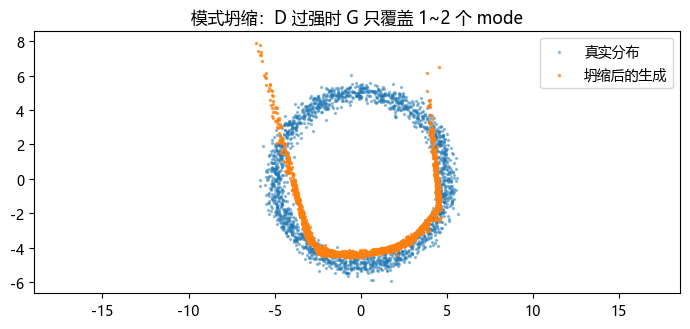

→ 判别器太强 = 梯度信号太少 = 生成器困在局部。这就是 GAN 训练平衡难的原因


In [2]:
# ---------- 实验 2：模式坍缩演示（D 过强 → G 只学少数模式） ----------
# 把判别器训练 10 步再训练生成器 1 步（严重失衡），G 会只覆盖少数 mode
torch.manual_seed(1)
G2 = nn.Sequential(nn.Linear(2, 32), nn.ReLU(), nn.Linear(32, 2))
D2 = nn.Sequential(nn.Linear(2, 32), nn.ReLU(), nn.Linear(32, 1))
optG2 = torch.optim.Adam(G2.parameters(), lr=1e-3)
optD2 = torch.optim.Adam(D2.parameters(), lr=1e-3)

for it in range(2500):
    for _ in range(10):                       # D 练 10 步
        xr = sample_real(128); xf = G2(sample_z(128))
        lossD = bce(D2(xr), torch.ones(128, 1)) + bce(D2(xf.detach()), torch.zeros(128, 1))
        optD2.zero_grad(); lossD.backward(); optD2.step()
    lossG = bce(D2(G2(sample_z(128))), torch.ones(128, 1))
    optG2.zero_grad(); lossG.backward(); optG2.step()

with torch.no_grad():
    fake2 = G2(sample_z(2000)).numpy()
plt.figure(figsize=(7, 3.4))
plt.scatter(real[:, 0], real[:, 1], s=2, label='真实分布', alpha=0.4)
plt.scatter(fake2[:, 0], fake2[:, 1], s=2, label='坍缩后的生成', alpha=0.7)
plt.legend(); plt.title('模式坍缩：D 过强时 G 只覆盖 1~2 个 mode')
plt.axis('equal'); plt.tight_layout(); plt.show()
print('→ 判别器太强 = 梯度信号太少 = 生成器困在局部。这就是 GAN 训练平衡难的原因')


## 2. 训练不稳定与 WGAN（白板推导）

**三个老大难**：① 平衡难（D 太强/太弱都坏）；② 梯度消失（D 饱和，log(1−D)≈0）；③ 模式坍缩。

**WGAN 思路**：把 JS 散度换成 **Wasserstein 距离**（搬土距离，处处可导、不会饱和）：
`W(p_data, p_g) = sup_{‖f‖_L ≤ 1} E_x[f(x)] − E_z[f(G(z))]`

- 判别器改叫 **critic**：输出不再 sigmoid，而是尽可能拉开真假分数
- 约束 1-Lipschitz：早期 weight clipping；**WGAN-GP** 用梯度惩罚：
  `GP = λ·E[(‖∇_{x̂} D(x̂)‖₂ − 1)²]`，其中 `x̂ = ε·x_r + (1−ε)·x_f`（真假之间插值）

> 面试三连问：① WGAN 为什么稳？（Wasserstein 距离不饱和、梯度有意义）
> ② 为什么 GP 比 clip 好？（clip 逼参数到边界，容量浪费；GP 直接约束梯度范数）
> ③ critic 能训到收敛吗？（能，且不塌陷——与 GAN 不同）


iter    0  G-loss=0.003（负的 critic 分，越小越好）


iter  400  G-loss=-0.274（负的 critic 分，越小越好）


iter  800  G-loss=-3.000（负的 critic 分，越小越好）


iter 1200  G-loss=0.771（负的 critic 分，越小越好）


iter 1600  G-loss=-5.789（负的 critic 分，越小越好）


iter 2000  G-loss=-4.870（负的 critic 分，越小越好）


iter 2400  G-loss=-5.488（负的 critic 分，越小越好）


iter 2800  G-loss=-2.392（负的 critic 分，越小越好）


iter 3200  G-loss=-9.159（负的 critic 分，越小越好）


iter 3600  G-loss=-15.353（负的 critic 分，越小越好）


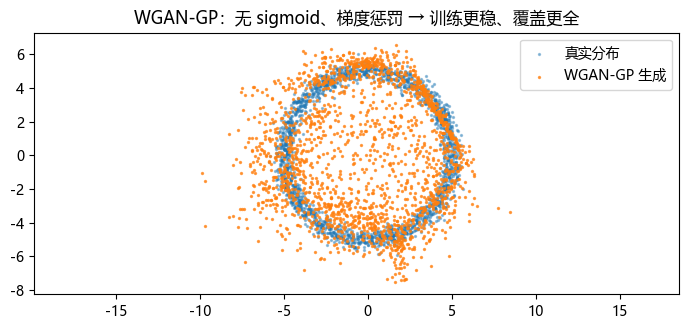

In [3]:
# ---------- 实验 3：WGAN-GP 在同一个环上训练（对比更稳） ----------
torch.manual_seed(0)
Gw = nn.Sequential(nn.Linear(2, 32), nn.ReLU(), nn.Linear(32, 2))
Cw = nn.Sequential(nn.Linear(2, 32), nn.ReLU(), nn.Linear(32, 1))   # critic 无 sigmoid
optGw = torch.optim.Adam(Gw.parameters(), lr=1e-3)
optCw = torch.optim.Adam(Cw.parameters(), lr=1e-3)
lam = 10.0

def gp_penalty(critic, xr, xf):
    eps = torch.rand(xr.shape[0], 1)
    x_hat = eps * xr + (1 - eps) * xf
    x_hat.requires_grad_(True)
    d = critic(x_hat)
    grads = torch.autograd.grad(outputs=d, inputs=x_hat,
                                grad_outputs=torch.ones_like(d), create_graph=True)[0]
    return lam * ((grads.norm(2, dim=1) - 1) ** 2).mean()

wl = []
for it in range(4000):
    for _ in range(5):                         # critic 5 步
        xr = sample_real(128); xf = Gw(sample_z(128)).detach()
        w = Cw(xr).mean() - Cw(xf).mean()      # Wasserstein 估计（最大化）
        gpl = gp_penalty(Cw, xr, xf)
        lossC = -w + gpl
        optCw.zero_grad(); lossC.backward(); optCw.step()
    lossGw = -Cw(Gw(sample_z(128))).mean()
    optGw.zero_grad(); lossGw.backward(); optGw.step()
    if it % 400 == 0:
        wl.append(lossGw.item())
        print('iter %4d  G-loss=%.3f（负的 critic 分，越小越好）' % (it, lossGw.item()))

with torch.no_grad():
    fake_w = Gw(sample_z(2000)).numpy()
plt.figure(figsize=(7, 3.4))
plt.scatter(real[:, 0], real[:, 1], s=2, label='真实分布', alpha=0.4)
plt.scatter(fake_w[:, 0], fake_w[:, 1], s=2, label='WGAN-GP 生成', alpha=0.7)
plt.legend(); plt.title('WGAN-GP：无 sigmoid、梯度惩罚 → 训练更稳、覆盖更全')
plt.axis('equal'); plt.tight_layout(); plt.show()


## 3. DCGAN 与 cGAN 要点（背就完事）

**DCGAN**（用卷积做 GAN）：
- G：全卷积转置（`ConvTranspose2d` 上采样），**BN 在 G 和 D 的判别头不用**
- D：普通卷积 + LeakyReLU + 最后展平打分
- 经验：不用全连接、不用 pooling（卷积替代）、G 输出层 tanh、D 输入层不用 BN

**cGAN 条件化**（按条件生成，如“画一只猫”）：
`min_G max_D  E[log D(x|y)] + E[log(1 − D(G(z|y)))]`——把条件 y（类别/文本）拼进 G 和 D 的输入。

**现代谱系**：GAN（2014）→ DCGAN（2015）→ WGAN/WGAN-GP（2017）→ StyleGAN（2018）→ 扩散（2020）
> 面试观点：图像生成如今扩散占优，但 GAN 在**速度/低维/特定域**仍强，且思想是必考的。

## 4. 自测清单

- [ ] 能写出 minimax 目标并推导最优判别器 D* = p_data/(p_data+p_g)
- [ ] 能说明非饱和损失（−log D(G(z))）解决什么
- [ ] 能解释模式坍缩与训练不稳定的机制（D 过强/饱和/平衡）
- [ ] 能写出 WGAN-GP 的目标与 GP 公式，并对比 JS/Wasserstein
- [ ] 能说出 DCGAN 结构要点（转置卷积/BN/LeakyReLU/tanh）与 cGAN 条件化公式

## 🎤 面试速答（背诵骨架）

- **目标**：min_G max_D log D(x) + log(1−D(G(z)))；D* = p_data/(p_data+p_g)；等价最小化 JSD
- **非饱和**：G 用 −log D(G(z)) 防梯度消失
- **WGAN**：Wasserstein 距离 + critic（无 sigmoid）+ GP：λ·E[(‖∇D‖−1)²]
- **DCGAN**：ConvTranspose 上采样、BN、LeakyReLU、G 输出 tanh
- **cGAN**：条件 y 拼进 G/D 输入；模式坍缩 = 覆盖不全、多样性丢失
